## Step 2: Data Collection



### Import necessary Libraries

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,roc_auc_score

###Import Dataset

In [ ]:
claimants_data = pd.read_csv("claimants.csv")

##Step 3: Data Understanding

###Perform Initial Investigation

In [ ]:
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [ ]:
claimants_data.shape

(1340, 7)

In [ ]:
claimants_data.isna().sum()

,0
CASENUM,0
ATTORNEY,0
CLMSEX,12
CLMINSUR,41
SEATBELT,48
CLMAGE,189
LOSS,0


In [ ]:
claimants_data.dtypes

,0
CASENUM,int64
ATTORNEY,int64
CLMSEX,float64
CLMINSUR,float64
SEATBELT,float64
CLMAGE,float64
LOSS,float64


In [ ]:
claimants_data.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1340.000000,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000
mean,11202.001493,0.488806,0.558735,0.907621,0.017028,28.414422,3.806307
std,9512.750796,0.500061,0.496725,0.289671,0.129425,20.304451,10.636903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4177.000000,0.000000,0.000000,1.000000,0.000000,9.000000,0.400000
50%,8756.500000,0.000000,1.000000,1.000000,0.000000,30.000000,1.069500
75%,15702.500000,1.000000,1.000000,1.000000,0.000000,43.000000,3.781500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,173.604000


##Step 4: Data Preparation

### Removing Null entries

In [ ]:
claimants_data.dropna(inplace=True)

In [ ]:
claimants_data.isna().sum()

,0
CASENUM,0
ATTORNEY,0
CLMSEX,0
CLMINSUR,0
SEATBELT,0
CLMAGE,0
LOSS,0


###Separation of Input and Output

In [ ]:
X = claimants_data.drop(labels=["CASENUM","ATTORNEY"],axis=1)

In [ ]:
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [ ]:
y= claimants_data["ATTORNEY"]
y

,ATTORNEY
0,0
1,1
2,1
3,0
4,1
...,...
1334,1
1336,0
1337,1
1338,0


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 13,
    shuffle=True,

)

##Step 5: Model Building

###Hyperparameter Tuning-gridsearchCV

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=5)

In [ ]:
grid_search = GridSearchCV(estimator=dt_model,param_grid={"max_depth":[5,6,7,8,9,10],"criterion":["gini","entropy"]})
grid_search.fit(X,y)
print(grid_search.best_params_)
print(grid_search.best_score_)


{'criterion': 'gini', 'max_depth': 5}
0.7253507679535076


##Step6: Model Training

In [ ]:
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

###Decision Tree Plot

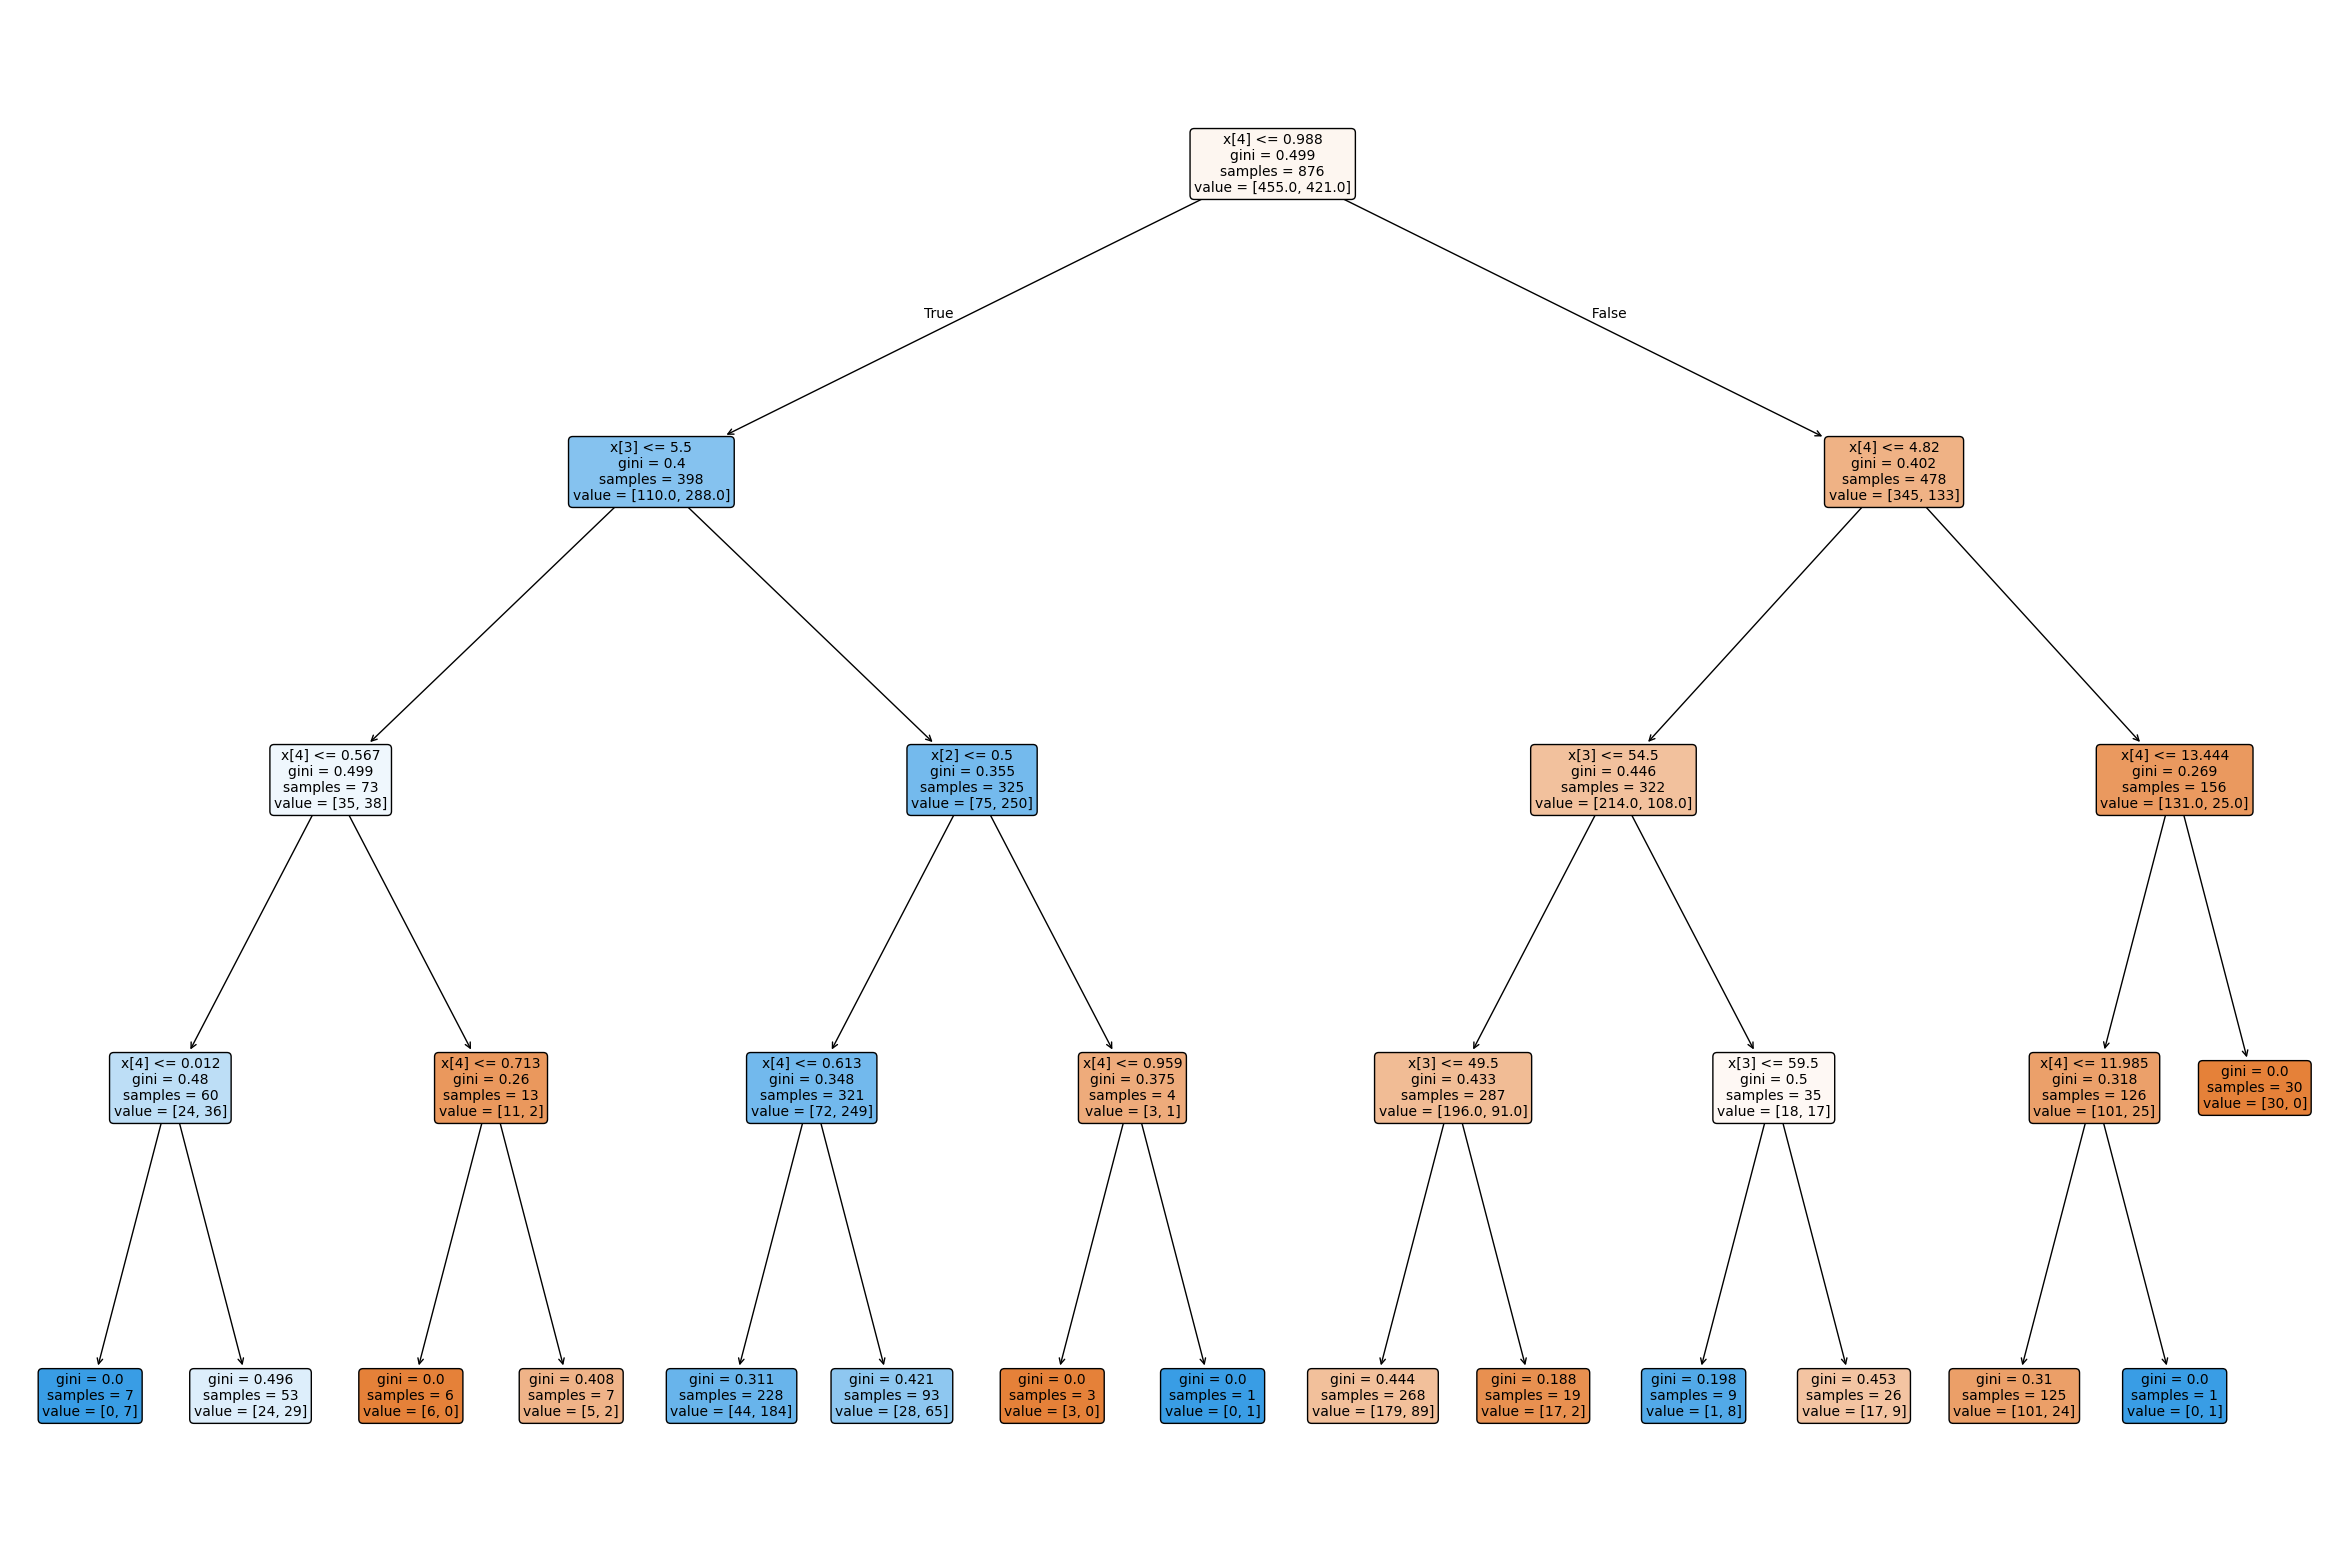

In [ ]:
plt.figure(figsize=(30,20))
plot_tree(decision_tree=dt_model,fontsize=10,filled=True,rounded=True)
plt.show()

##Step7: Model Testing

### Training data prediction

In [ ]:
y_pred_train = dt_model.predict(X_train)

###Testing Data Prediction

In [ ]:
y_pred_test = dt_model.predict(X_test)

##Step8: Model Evaluation

### Evaluation for Training data prediction

###Confusion_matrix

In [ ]:
print(confusion_matrix(y_train,y_pred_train))

[[395  60]
 [154 267]]


####Classification report

In [ ]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.72      0.87      0.79       455
           1       0.82      0.63      0.71       421

    accuracy                           0.76       876
   macro avg       0.77      0.75      0.75       876
weighted avg       0.77      0.76      0.75       876



### Roc curve

auc_score 0.8144945315966694


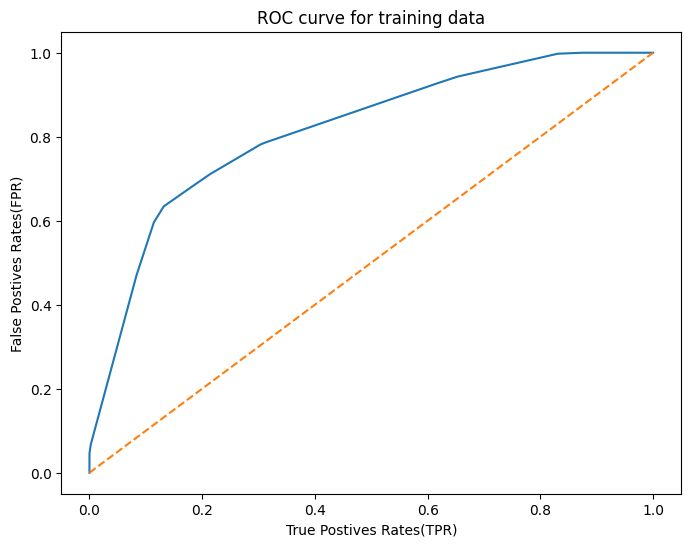

In [ ]:
y_prob = dt_model.predict_proba(X_train)[:,1]
fpr,tpr,threshold =roc_curve(y_train,
          y_prob,)
auc_score = roc_auc_score(y_train,
                          y_prob)
print("auc_score",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle="--")
plt.title("ROC curve for training data")
plt.xlabel("True Postives Rates(TPR)")
plt.ylabel("False Postives Rates(FPR)")
plt.show()



###Evaluation for Testing data Prediction

####Confusion Matrix for Test data

In [ ]:
print(confusion_matrix(y_test,y_pred_test))

[[98 25]
 [42 55]]


####Classification Report for Test Data

In [ ]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.70      0.80      0.75       123
           1       0.69      0.57      0.62        97

    accuracy                           0.70       220
   macro avg       0.69      0.68      0.68       220
weighted avg       0.69      0.70      0.69       220



####Roc Curve for test data

auc_score: 0.7635571201072835


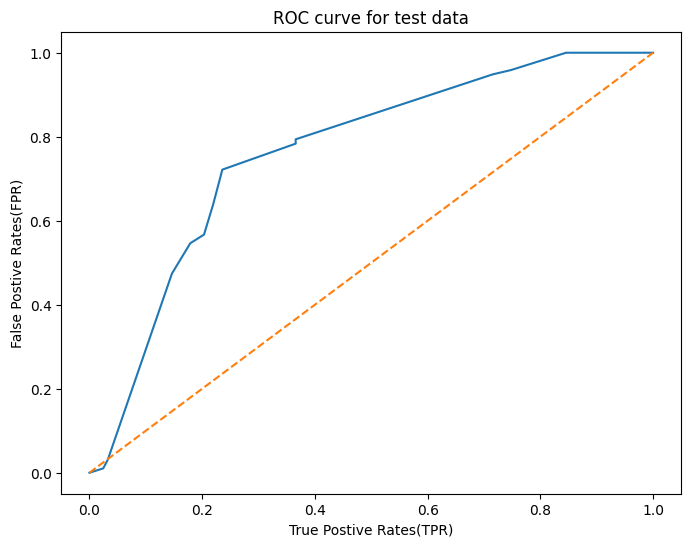

In [ ]:
y_prob = dt_model.predict_proba(X_test)[:,1]
fpr,tpr,threshold = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)
print("auc_score:",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle="--")
plt.title("ROC curve for test data")
plt.xlabel("True Postive Rates(TPR)")
plt.ylabel("False Postive Rates(FPR)")
plt.show()